# 05 — Récidive client et charge de traitement

**Objectif** — montrer que le volume de réclamations n'est pas une mesure de la
demande, mais en partie une mesure de l'échec du traitement.

| | |
|---|---|
| **Entrée** | période opérationnelle complète (voir note de périmètre ci-dessous) |
| **Sorties** | `resultats/tables/05_*.csv` + 2 figures |
| **Suite** | notebook 06 — synthèse |

**Note de périmètre — pourquoi il diffère du notebook 04**

Le notebook 04 travaille sur six mois seulement, parce qu'il a besoin du **texte**,
détruit par la panne de mars-mai. Ce notebook n'utilise que des champs système —
identifiant client, type, horodatages — qui, eux, ont continué d'être alimentés
pendant la panne. Il travaille donc sur la **période opérationnelle complète**
(18 056 tickets).

Le périmètre se déduit de la question posée, pas d'une règle appliquée une fois
pour toutes. Chaque notebook explicite le sien.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from reclamations import chargement, config, viz

viz.appliquer_charte()
pd.set_option("display.width", 160)

df = chargement.typer(chargement.charger_brut())
op = chargement.perimetre_operationnel(df)

print(f"Tickets : {len(op):,}")
print(f"Identifiant client renseigné : {op['contact_id'].notna().mean() * 100:.1f} %")
print(f"Clients distincts : {op['contact_id'].nunique():,}")

Tickets : 18,056
Identifiant client renseigné : 100.0 %
Clients distincts : 10,929


## 1. Combien de tickets par client ?

Premier changement d'unité d'analyse : on ne compte plus des tickets, on compte
des clients.

In [2]:
par_client = op["contact_id"].value_counts()
distribution = par_client.value_counts().sort_index().rename("nb_clients")
distribution.index.name = "reclamations_deposees"
chargement.sauver_table(distribution.to_frame(), "05_distribution_par_client")

pct_recidivistes = (par_client >= 2).mean() * 100
pct_volume = par_client[par_client >= 2].sum() / par_client.sum() * 100
print(f"Clients ayant déposé >= 2 réclamations : {pct_recidivistes:.1f} %")
print(f"Part du volume qu'ils représentent     : {pct_volume:.1f} %")
distribution.head(10)

  -> resultats\tables\05_distribution_par_client.csv
Clients ayant déposé >= 2 réclamations : 33.8 %
Part du volume qu'ils représentent     : 59.9 %


reclamations_deposees
1     7233
2     2113
3      820
4      352
5      178
6       93
7       60
8       27
9       15
10      10
Name: nb_clients, dtype: int64

> **Un tiers des clients concentre 60 % du volume.** Ce n'est pas 18 000 clients
> mécontents : c'est ~11 000 clients dont une partie doit s'y reprendre à
> plusieurs fois.

Reste à savoir si ces dépôts répétés sont des problèmes **nouveaux** ou des
**relances** sur un dossier qui n'avance pas. C'est la distinction qui décide de
l'interprétation.

## 2. Relance ou nouveau problème ?

Test : pour chaque paire de réclamations consécutives d'un même client, on
mesure le délai qui les sépare et si elles portent sur le même type. Une
relance devrait être **rapprochée** et **de même motif** ; un nouveau problème
serait éloigné dans le temps et de motif indépendant.

In [3]:
suivi = op.sort_values(["contact_id", "date_creation"]).copy()
suivi["delai_depuis_precedent_j"] = (
    suivi.groupby("contact_id")["date_creation"].diff().dt.total_seconds() / 86400
)
suivi["meme_type"] = suivi["ticket_type_name"] == suivi.groupby("contact_id")[
    "ticket_type_name"
].shift()

paires = suivi.dropna(subset=["delai_depuis_precedent_j"])
tranches = [(0, 1), (1, 3), (3, 7), (7, 30), (30, 10_000)]
lignes = []
for lo, hi in tranches:
    s = paires[(paires["delai_depuis_precedent_j"] >= lo) & (paires["delai_depuis_precedent_j"] < hi)]
    lignes.append(
        {
            "tranche_jours": f"{lo}-{hi}" if hi < 10_000 else f"> {lo}",
            "nb_paires": len(s),
            "pct_meme_type": round(s["meme_type"].mean() * 100, 1),
        }
    )
tranche_table = pd.DataFrame(lignes).set_index("tranche_jours")
chargement.sauver_table(tranche_table, "05_relance_par_tranche")
tranche_table

  -> resultats\tables\05_relance_par_tranche.csv


,nb_paires,pct_meme_type
tranche_jours,,
0-1,2440,81.1
1-3,1119,81.7
3-7,813,76.8
7-30,1146,67.6
> 30,1609,58.0


**Le gradient est net et va dans le sens attendu d'une relance** : 81 % de même
motif à moins de 3 jours, puis décroissance régulière jusqu'à 58 % au-delà d'un
mois. Plus deux dépôts sont rapprochés, plus ils portent sur le même sujet.

C'est ce gradient qui justifie le seuil retenu pour qualifier un re-dépôt —
`config.FENETRE_REDEPOT_JOURS` = 7 jours, avec même motif.

In [4]:
suivi["redepot"] = (
    suivi["delai_depuis_precedent_j"] < config.FENETRE_REDEPOT_JOURS
) & suivi["meme_type"]
n_redepot = int(suivi["redepot"].sum())
print(f"Re-dépôts (< 7 j, même motif) : {n_redepot:,} soit {n_redepot / len(op) * 100:.1f} % du volume")
print(f"  dont sous 24 h : {int(((suivi['delai_depuis_precedent_j'] < 1) & suivi['meme_type']).sum()):,}")

Re-dépôts (< 7 j, même motif) : 3,518 soit 19.5 % du volume
  dont sous 24 h : 1,980


## 3. La charge que cela représente

Un ticket n'est pas une unité de travail : une conversation de 60 messages coûte
plus qu'une de 10. On mesure donc la charge en **messages échangés**.

In [5]:
total_messages = op["nb_messages"].sum()
messages_redepot = suivi.loc[suivi["redepot"], "nb_messages"].sum()
nb_agents = op["admin_assignee_id"].nunique()
nb_mois = op["mois"].nunique()

print(f"Messages échangés (période)   : {total_messages:,.0f}")
print(f"Médiane par ticket            : {op['nb_messages'].median():.0f}")
print(f"Minimum par ticket            : {op['nb_messages'].min():.0f}")
print(f"Agents distincts              : {nb_agents}")
print(f"-> messages / agent / mois    : {total_messages / nb_mois / nb_agents:,.0f}")
print()
print(f"Messages liés aux re-dépôts   : {messages_redepot:,.0f} "
      f"({messages_redepot / total_messages * 100:.1f} % de la charge)")

Messages échangés (période)   : 501,399
Médiane par ticket            : 26
Minimum par ticket            : 7
Agents distincts              : 7
-> messages / agent / mois    : 7,959

Messages liés aux re-dépôts   : 95,052 (19.0 % de la charge)


> Le minimum est de **7 messages** et la médiane de **26**, pour des dossiers
> dont l'énoncé tient en une phrase (« transfert de 15 000 vers Orange Money non
> abouti, compte débité »). Le traitement est intégralement conversationnel :
> aucune information n'est capturée sous forme structurée à l'entrée, il faut
> donc la redemander.

## 4. Le taux de clôture

Contexte indispensable pour interpréter la récidive.

In [6]:
statuts = op["ticket_state_category"].value_counts(normalize=True).mul(100).round(2)
chargement.sauver_table(statuts.to_frame("pct"), "05_statuts")
statuts

  -> resultats\tables\05_statuts.csv


ticket_state_category
submitted              90.29
resolved                9.25
in_progress             0.36
waiting_on_customer     0.09
Name: proportion, dtype: float64

**Précaution de lecture.** Le statut `submitted` peut désigner soit une
réclamation en attente, soit un état final de workflow dans lequel les tickets
sont figés après traitement. L'indicateur booléen `open` n'est vrai que pour
0,27 % des tickets, ce qui suggère la seconde lecture — mais les deux champs ne
mesurent visiblement pas la même chose.

> **À clarifier avec l'équipe support avant toute communication d'un « taux de
> résolution ».** En l'état, ce champ ne permet pas de dire si 90 % des dossiers
> sont en souffrance ou simplement archivés.

## 5. La boucle de rétroaction

Dernier test, et le plus important : le taux de re-dépôt est-il stable, ou
augmente-t-il quand le système est sous tension ?

In [7]:
boucle = suivi.groupby("mois").agg(
    volume=("id", "size"),
    taux_redepot=("redepot", "mean"),
    clients=("contact_id", "nunique"),
)
chargement.sauver_table(boucle.round(3), "05_boucle_retroaction")
boucle.round(3)

  -> resultats\tables\05_boucle_retroaction.csv


,volume,taux_redepot,clients
mois,,,
2025-11,600,0.103,506
2025-12,1605,0.155,1281
2026-01,1467,0.158,1157
2026-02,1372,0.142,1101
2026-03,4087,0.201,2967
2026-04,5228,0.243,3536
2026-05,1874,0.184,1472
2026-06,1333,0.182,1038
2026-07,490,0.204,385


  -> resultats\figures\05_boucle_retroaction.png


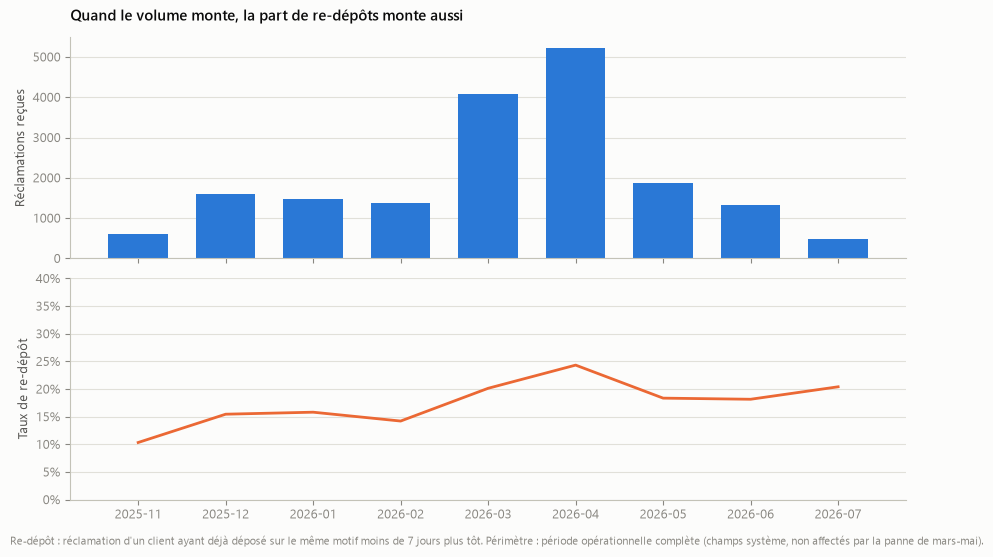

In [8]:
fig, axes = viz.panneaux_temporels(
    [str(m) for m in boucle.index],
    [
        {
            "valeurs": boucle["volume"],
            "libelle": "Réclamations reçues",
            "couleur": viz.SERIES[0],
            "type": "barres",
            "largeur": 0.68,
        },
        {
            "valeurs": boucle["taux_redepot"],
            "libelle": "Taux de re-dépôt",
            "couleur": viz.SERIES[1],
            "type": "ligne",
            "pct": True,
        },
    ],
    titre="Quand le volume monte, la part de re-dépôts monte aussi",
)
axes[1].set_ylim(0, 0.4)
viz.annoter_source(
    fig,
    "Re-dépôt : réclamation d'un client ayant déjà déposé sur le même motif moins de 7 jours plus tôt. "
    "Périmètre : période opérationnelle complète (champs système, non affectés par la panne de mars-mai).",
)
viz.sauver(fig, "05_boucle_retroaction")
plt.show()

## 6. Conclusion du notebook

Le taux de re-dépôt passe de 15-19 % en régime normal à **30 % en avril 2026**,
au plus fort de l'afflux. Le système ne se contente pas de subir la charge : il
**en produit une partie**.

> Plus le traitement est lent, plus les clients relancent ; plus ils relancent,
> plus le traitement est lent. Le volume de réclamations mesure donc en partie
> la performance du dispositif, et non la seule insatisfaction des clients.

**Conséquence directe sur le choix de l'indicateur de succès** — un projet dont
l'objectif serait « faire baisser le nombre de réclamations » se donnerait une
cible que l'on peut atteindre en dégradant le canal de dépôt. L'indicateur doit
porter sur le **taux d'incident par transaction**, pas sur le compte de plaintes.
Ce point est repris et argumenté au notebook 06.